# Payment Protection Insurance: Behavioral Time-Series Default Modeling
### American Express Default Prediction data, with an insurance pricing focus

**Author:** Khushi Advani · **Revised:** September 2026

Can 13 months of card-statement history tell us **who will default, and how early**, well enough to
(1) price a Payment Protection Insurance (PPI) product by risk and (2) justify contacting at-risk
customers before they default?

All logic lives in the `amex_ppi` package (`src/amex_ppi/`). This notebook runs it step by step on
**real AMEX data** and explains each result. `python -m amex_ppi.run` reproduces the same numbers
and figures from the command line.

**Contents**
1. Setup & data
2. Behavioral patterns
3. Feature engineering
4. Model comparison
5. Do trajectory features help? (ablation)
6. How early can we predict? (horizon analysis)
7. Probability calibration
8. Risk-based pricing
9. Early-intervention economics
10. Explainability (SHAP)
11. Conclusions, limitations & regulatory notes

## 1. Setup & data

**Data:** [American Express – Default Prediction](https://www.kaggle.com/competitions/amex-default-prediction)
(Kaggle, 2022). ~459k customers, monthly statements March 2017 – March 2018, 188 anonymized features
grouped by prefix: `D_` delinquency, `S_` spend, `P_` payment, `B_` balance, `R_` risk. The label
is whether the customer defaults (no payment due within 120 days) in the 18 months after their last
statement.

**One-time preparation.** Download the competition files to `~/amex_data`, then build a
customer-level random sample (streams the 16 GB CSV in chunks; takes about 10 minutes):

```bash
kaggle competitions download -c amex-default-prediction -p ~/amex_data && unzip ~/amex_data/amex-default-prediction.zip -d ~/amex_data
python -m amex_ppi.data --raw-dir ~/amex_data --out data/amex_sample.parquet --n-customers 50000
```

Keep `kaggle.json` in `~/.kaggle/` and **never** in the repo (it is git-ignored).

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))  # works without `pip install -e .`
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from amex_ppi import models as M, intervention as iv, plots
from amex_ppi.data import load_statements, make_synthetic
from amex_ppi.features import customer_features
from amex_ppi.metrics import evaluate, calibration_table
from amex_ppi.pricing import PricingAssumptions, gross_premium, experience_loss_ratio, pricing_table
from amex_ppi.run import compare_models, feature_ablation, horizon_analysis, payment_trajectory, shap_values

pd.set_option("display.float_format", "{:,.4f}".format)
SEED = 42
DATA_PATH = Path("data/amex_sample.parquet")
USE_SYNTHETIC = False  # True only to smoke-test the code; synthetic results mean nothing

if USE_SYNTHETIC:
    statements = make_synthetic(seed=SEED)
elif DATA_PATH.exists():
    statements = load_statements(DATA_PATH)
else:
    raise FileNotFoundError(f"{DATA_PATH} not found. Run the preparation step above first.")

n_cust = statements["customer_ID"].nunique()
print(f"{len(statements):,} statements | {n_cust:,} customers | "
      f"{len(statements) / n_cust:.1f} statements/customer")
print(f"Default rate: {statements.groupby('customer_ID')['target'].first().mean():.1%}")
print(statements.groupby("customer_ID").size().value_counts().sort_index().rename("customers by # statements").to_string())

602,234 statements | 50,000 customers | 12.0 statements/customer
Default rate: 25.9%
1       572
2       707
3       602
4       498
5       510
6       626
7       574
8       654
9       695
10      731
11      673
12     1128
13    42030


## 2. Behavioral patterns

`P_2` is the feature most associated with default in this competition and is generally read as a
payment ratio. Aligning every customer on their **last** statement shows how the two groups diverge
over time.

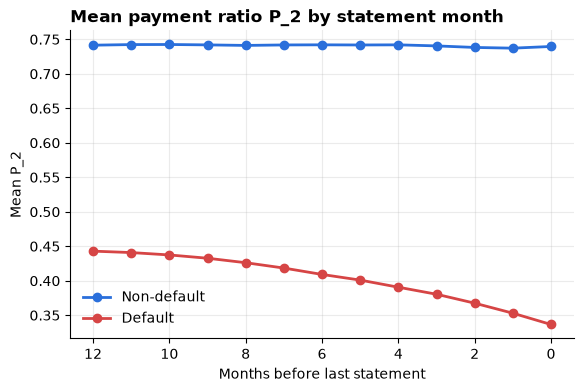

Non-default : P_2 0.742 -> 0.740 (-0.3%)
Default     : P_2 0.443 -> 0.337 (-24.0%)


In [2]:
traj = payment_trajectory(statements)
plots.payment_trajectory(traj); plt.show()
first, last = traj.index.max(), 0
for label, col in [("Non-default", 0), ("Default", 1)]:
    print(f"{label:12s}: P_2 {traj.loc[first, col]:.3f} -> {traj.loc[last, col]:.3f} "
          f"({traj.loc[last, col] / traj.loc[first, col] - 1:+.1%})")

The picture shows a **level** gap (defaulters pay less from the start) *and* a **trend** (their
payments keep falling). The level gap alone would make default predictable without any time series.
Section 5 tests whether the trend adds anything beyond it.

## 3. Feature engineering

`customer_features` builds one row per customer at three nested levels:

| Set | Contents |
|---|---|
| `snapshot` | last statement only, plus one-hot of the latest categorical values |
| `aggregate` | + mean / std / min / max over history, categorical change counts |
| `trajectory` | + OLS slope, first→last change, last-3-months vs. history shift, 3-month average, month-over-month volatility, mean % change |

Compared with the original version:
* **All** numeric features are used, not an arbitrary first 20.
* Categorical columns (`D_63`, `D_64`, `B_30` …) are one-hot encoded instead of being treated as numbers.
* `pct_change` on zero balances (±∞) is guarded, and missing values stay `NaN`: missingness carries
  signal in this data, and LightGBM handles it natively.

In [3]:
X, y = customer_features(statements, "trajectory")
ids = M.split_ids(y, SEED)
print(f"Feature matrix: {X.shape[0]:,} customers x {X.shape[1]:,} features")
print({k: len(v) for k, v in ids.items()}, "(train / validation / test, stratified)")

Feature matrix: 50,000 customers x 2,014 features
{'train': 30000, 'val': 10000, 'test': 10000} (train / validation / test, stratified)


## 4. Model comparison

Three models, each fit on **train** only:
* **Logistic regression**: median imputation + standardization + L2 (the original fit it on raw,
  unscaled features, which handicaps it unfairly).
* **Random forest**: no `class_weight="balanced"`, because reweighting distorts probabilities and
  we price off them.
* **LightGBM**: early-stopped on validation.

The best model is chosen on **validation** AUC. The test set is used only for reporting. The
original picked the winner on the test set and then priced the same customers, which biases every
downstream number. We also report the competition's **AMEX M** metric (normalized Gini + top-4%
capture) so results can be compared with the leaderboard.

auc   gini  amex_m  brier  log_loss
model               split                                            
Logistic Regression validation 0.9449 0.8897  0.7285 0.0824    0.2720
                    test       0.9470 0.8939  0.7414 0.0796    0.2689
Random Forest       validation 0.9471 0.8941  0.7263 0.0815    0.2599
                    test       0.9499 0.8997  0.7397 0.0794    0.2550
LightGBM            validation 0.9551 0.9102  0.7583 0.0743    0.2367
                    test       0.9574 0.9147  0.7792 0.0712    0.2298

Selected on validation: LightGBM


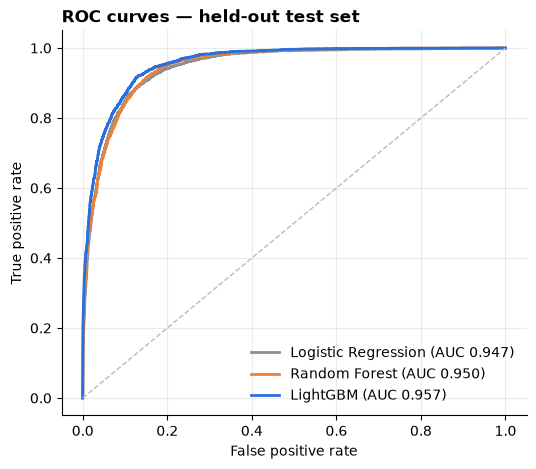

In [4]:
fitted, model_table, test_preds, best = compare_models(X, y, ids, SEED)
display(model_table)
print(f"Selected on validation: {best}")
plots.roc_curves(y.loc[ids["test"]], test_preds, model_table.xs("test", level="split")["auc"].to_dict()); plt.show()

## 5. Do trajectory features help?

The paper's central claim is that modeling **trends** beats treating each month in isolation. We
test it directly by training the same LightGBM on each feature set and scoring on the same test
customers.

,n_features,auc,gini,amex_m,brier,log_loss
snapshot,233.0000,0.9551,0.9102,0.7702,0.0730,0.2345
aggregate,952.0000,0.9566,0.9133,0.7789,0.0716,0.2316
trajectory,"2,014.0000",0.9574,0.9147,0.7792,0.0712,0.2298


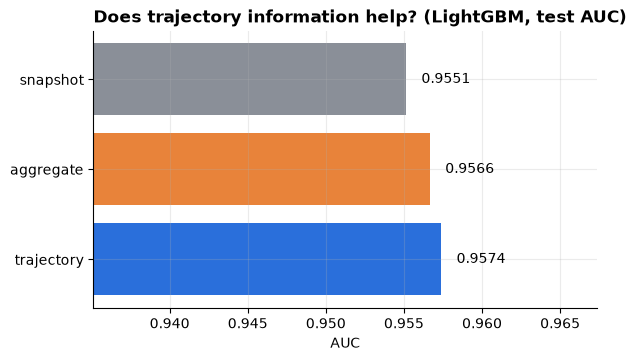

In [5]:
ablation = feature_ablation(statements, y, ids, X, SEED)
display(ablation)
plots.feature_ablation(ablation); plt.show()

**Interpretation.** On the 50k-customer real sample, trajectory features beat the last-statement
snapshot, but **only by about 0.002 AUC**. Most of the predictive signal is already in the latest
statement. Trends give a small, consistent improvement on every metric, not a step change. That is
a more defensible claim than "time-series features are the key".

## 6. How early can we predict default?

The original "6-month early-warning window" came from eyeballing when the average `P_2` curves
diverge, not from a test. Here we **withhold each customer's most recent *k* statements**, retrain,
and score. If AUC holds up as *k* grows, the signal really is available *k* months earlier.
(Restricted to customers with all 13 statements so every horizon scores the same people.)

  horizon 0: AUC 0.9617


  horizon 1: AUC 0.9572


  horizon 2: AUC 0.9508


  horizon 3: AUC 0.9468


  horizon 4: AUC 0.9418


  horizon 5: AUC 0.9375


  horizon 6: AUC 0.9341


,statements_used,auc,gini,amex_m,brier,log_loss
months_withheld,,,,,,
0,13.0000,0.9617,0.9234,0.7985,0.0643,0.2090
1,12.0000,0.9572,0.9145,0.7884,0.0686,0.2222
2,11.0000,0.9508,0.9015,0.7564,0.0733,0.2373
3,10.0000,0.9468,0.8935,0.7400,0.0766,0.2468
4,9.0000,0.9418,0.8836,0.7095,0.0805,0.2577
5,8.0000,0.9375,0.8750,0.7049,0.0830,0.2653
6,7.0000,0.9341,0.8682,0.6915,0.0858,0.2728


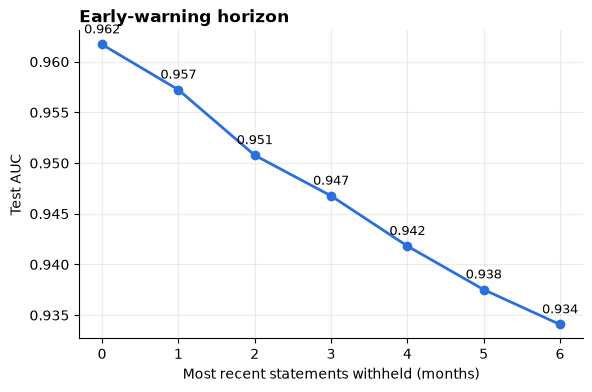

In [6]:
horizon = horizon_analysis(statements, ids, horizons=range(7), seed=SEED)
display(horizon)
plots.horizon(horizon); plt.show()

**Interpretation.** AUC falls slowly as recent statements are withheld and is still above 0.93
with six months removed. So there is real evidence for a multi-month early-warning window, now
backed by a test instead of a chart reading. The cost of acting earlier is a steady loss of
accuracy, which intervention timing has to trade off.

## 7. Probability calibration

Premiums are `probability × claim amount`, so **ranking** quality (AUC) is not enough. The
probabilities themselves must be right. We calibrate the selected model with isotonic regression
fit on the validation set and check it on test.

,uncalibrated,calibrated
auc,0.9574,0.9569
gini,0.9147,0.9138
amex_m,0.7792,0.7792
brier,0.0712,0.0713
log_loss,0.2298,0.2305


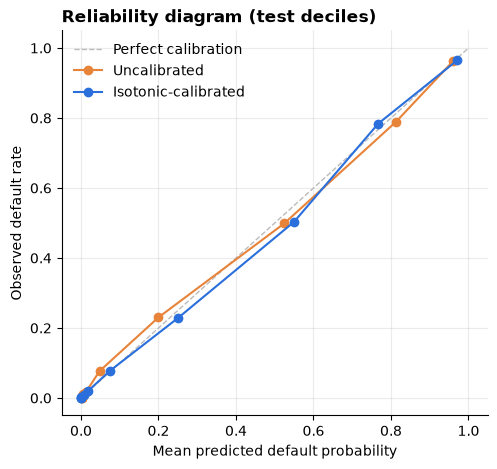

In [7]:
best_model = fitted[best]
calibrated = M.calibrate(best_model, X.loc[ids["val"]], y.loc[ids["val"]])
yv, yt = y.loc[ids["val"]], y.loc[ids["test"]]
pv = M.predict(calibrated, X.loc[ids["val"]])
pt = M.predict(calibrated, X.loc[ids["test"]])
pt_raw = test_preds[best]

display(pd.DataFrame({"uncalibrated": evaluate(yt, pt_raw), "calibrated": evaluate(yt, pt)}))
plots.calibration(calibration_table(yt, pt_raw), calibration_table(yt, pt)); plt.show()

**Interpretation.** LightGBM trained on log-loss *without* class reweighting is already close to
calibrated, so isotonic calibration changes almost nothing here. Checking was still worth it: the
original random forest used `class_weight="balanced"`, which inflates probabilities and would
have overpriced every customer.

## 8. Risk-based pricing

**Fixing the premium formula.** The original computed `premium = expected_loss × (1 + 0.15 + 0.25)`.
That makes the loss ratio exactly 1/1.40 = **71.4% whatever the model does**, so the reported "71.5%
loss ratio" restated an assumption rather than measuring anything. Standard practice loads expenses
and profit as shares of the *premium*:

$$\text{gross premium} = \frac{p \times \text{claim amount}}{1 - \text{expense ratio} - \text{profit margin}}$$

The *target* loss ratio (60% here) is still an input. The real test is the **experience loss
ratio**: actual test-set claims ÷ premiums charged. It only hits target if the probabilities are
calibrated. We compare against a **flat** premium set at the training-set default rate.

*Assumption:* AMEX features are anonymized, so the $5,000 average benefit is assumed, not observed.

,value
Target loss ratio (input),60.0%
"Experience LR, risk-based (calibrated)",58.9%
"Experience LR, risk-based (uncalibrated)",60.4%
"Experience LR, flat premium",60.0%


,customers,predicted_rate,actual_rate,risk_premium,flat_premium,loss_ratio_risk,loss_ratio_flat
band,,,,,,,
Very Low,2000,0.0004,0.0015,3.7036,"2,159.4444",2.0250,0.0035
Low,2000,0.0047,0.0050,39.3288,"2,159.4444",0.6357,0.0116
Medium,2000,0.0461,0.0485,383.8053,"2,159.4444",0.6318,0.1123
High,2000,0.4002,0.3660,"3,334.9880","2,159.4444",0.5487,0.8474
Very High,2000,0.8691,0.8745,"7,242.8137","2,159.4444",0.6037,2.0248


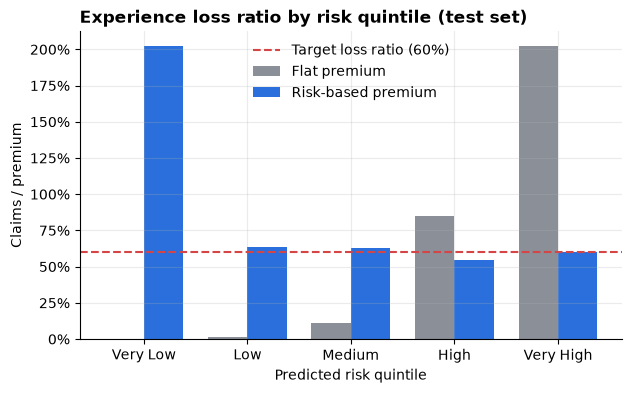

In [8]:
A = PricingAssumptions(claim_amount=5_000, expense_ratio=0.25, profit_margin=0.15)
flat_p = y.loc[ids["train"]].mean()

summary = pd.Series({
    "Target loss ratio (input)": A.target_loss_ratio,
    "Experience LR, risk-based (calibrated)": experience_loss_ratio(gross_premium(pt, A), yt, A),
    "Experience LR, risk-based (uncalibrated)": experience_loss_ratio(gross_premium(pt_raw, A), yt, A),
    "Experience LR, flat premium": experience_loss_ratio(gross_premium(np.full(len(yt), flat_p), A), yt, A),
}).map("{:.1%}".format)
display(summary.to_frame("value"))

price = pricing_table(pt, yt, flat_p, A)
display(price)
plots.loss_ratio_by_band(price, A.target_loss_ratio); plt.show()

**Reading the band table.** Under a flat premium, low-risk customers pay far more than their
expected claims (loss ratio well below target) and subsidize high-risk customers (loss ratio far
above). In a voluntary product, low-risk customers then leave and high-risk customers stay. That is
**adverse selection**, and it is the real business case for risk-based pricing. Risk-based
premiums bring every band close to target. Where the very-low band misses, it is because its
premiums are tiny, so in practice a minimum premium would apply.

## 9. Early-intervention economics

Each contacted customer costs \$200. A contact prevents default for 30% of the contacted customers
who *would* have defaulted, and each prevented default avoids a \$5,000 claim. The threshold is
chosen to **maximize net savings on validation** (the original hard-coded 0.4) and then applied
to test.

,test set
threshold,0.1100
flagged,"3,994.0000"
flagged_pct,0.3994
true_positives,"2,481.0000"
precision,0.6212
recall,0.9575
prevented_defaults,744.3000
program_cost,"798,800.0000"
claims_avoided,"3,721,500.0000"
net_savings,"2,922,700.0000"


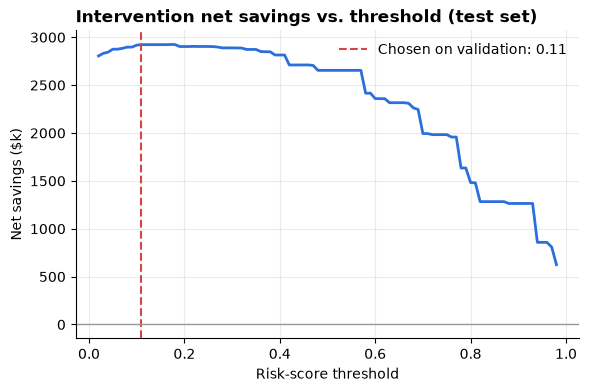

In [9]:
IA = iv.InterventionAssumptions(cost=200, success_rate=0.30, claim_amount=5_000)
threshold = iv.best_threshold(pv, yv, IA)
econ = iv.economics(pt, yt, threshold, IA)
display(pd.Series(econ).to_frame("test set"))
plots.threshold_curve(iv.threshold_curve(pt, yt, IA), threshold); plt.show()

**How much of the ROI comes from assumptions?** Almost all of it. The model decides *who* gets
contacted, but the dollar figure is set by the assumed success rate and cost. The grid below shows
net savings at the chosen threshold under other assumptions. `breakeven_success_rate` above is the
success rate at which the program just pays for itself, which is the number to validate with a
pilot.

cost / contact,$100 (net $k),$200 (net $k),$400 (net $k),$800 (net $k)
success rate,,,,
5%,221.0000,-179.0000,-977.0000,"-2,575.0000"
10%,841.0000,442.0000,-357.0000,"-1,955.0000"
20%,"2,082.0000","1,682.0000",883.0000,-714.0000
30%,"3,322.0000","2,923.0000","2,124.0000",526.0000
40%,"4,563.0000","4,163.0000","3,364.0000","1,767.0000"


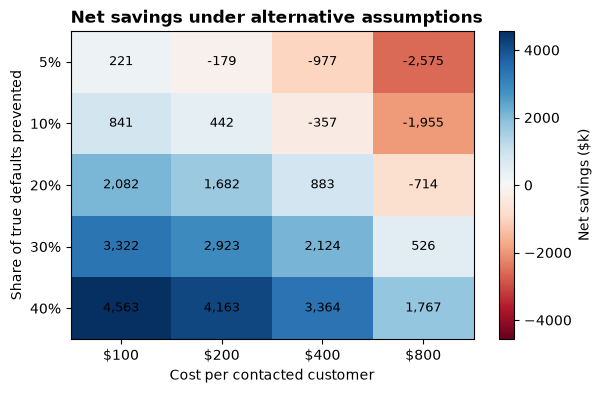

In [10]:
sens = iv.sensitivity(pt, yt, threshold, IA)
display((sens / 1e3).round(0).rename(columns=lambda c: f"{c} (net $k)"))
plots.sensitivity_heatmap(sens); plt.show()

## 10. Explainability (SHAP)

Insurance pricing models generally have to be explainable to regulators and customers. SHAP values
show which features drive the predictions. Blue bars are trajectory features.

/private/tmp/claude-501/-Users-kadvani-Library-Application-Support-Claude-scratch-workspaces-5b14d60f-d690-490e-bffa-36c02d4067f0-5960e1aa-ed41-4573-a7ac-2d3fdd26f9d1-scratch-2026-10-01-71431f/97fbde69-3ebf-4e83-910f-98f611de2cae/scratchpad/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


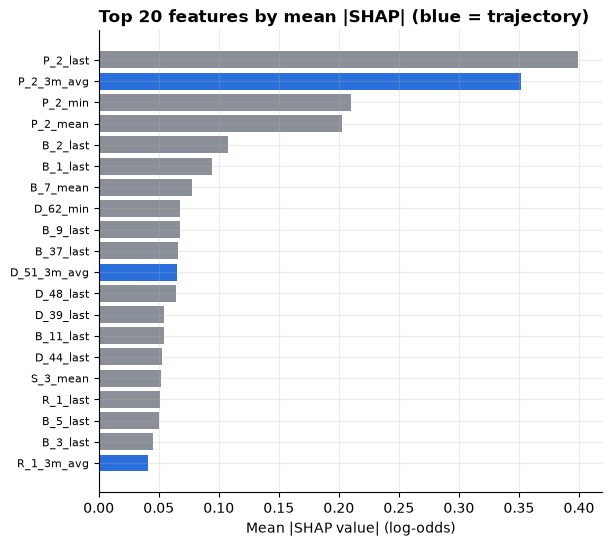

Share of total |SHAP| from trajectory features: 41.4%


In [11]:
if best == "LightGBM":
    mean_abs = shap_values(best_model, X.loc[ids["test"]], seed=SEED)
    plots.shap_importance(mean_abs); plt.show()
    traj_share = mean_abs[mean_abs.index.str.contains("_slope|_delta|_recent_shift|_diff_std|_pct_change|_3m_avg")].sum() / mean_abs.sum()
    print(f"Share of total |SHAP| from trajectory features: {traj_share:.1%}")
else:
    print(f"Best model is {best}; SHAP section expects LightGBM.")

## 11. Conclusions, limitations & regulatory notes

See the README for the headline numbers from this run. Main caveats:

* **Default is a stand-in for a PPI claim.** PPI pays out on involuntary unemployment, sickness or
  disability, not on default as such. Defaults caused by other things (e.g. over-spending) would not
  be claims. A production model needs claims data.
* **Adverse selection & moral hazard.** People who buy PPI are not a random sample of cardholders,
  and being insured can change behavior. Neither is visible in this data.
* **Assumed economics.** The claim amount, intervention cost and success rate are assumptions. The
  sensitivity grid and break-even rate show how far conclusions depend on them.
* **Sampled competition data.** AMEX sub-sampled non-defaulters, so the 26% default rate is far
  above a real portfolio's. Calibrated probabilities would need re-basing to the true prior before
  real pricing.
* **Regulation & fairness.** The UK PPI mis-selling scandal (more than £38bn in redress) shows how
  this product can harm consumers. Pricing on behavioral signals must be checked for proxy
  discrimination (fair-lending rules such as ECOA / Reg B in the US, FCA Consumer Duty in the UK), be
  explainable (Section 10), and offer interventions as *help*, not as a route to cancelling cover.